# Corporación Universitaria Iberoamericana

---

## Materia: Inteligencia Artificial

## Actividad 04

## Métodos de aprendizaje no supervisado

---

**Estudiante**  
Sthiben Jesus Ruiz Reyes  

**Profesor**  
Joaquin Fernando Sanchez Cifuentes  

**fecha**  
07 de junio de 2026


**Link Video Youtube**  
https://youtu.be/jNS9UikuAv0

**Link GitHub**  



# Agrupamiento de estaciones de TransMilenio usando Autoencoder y K-Means

## Objetivo del proyecto

El objetivo de este proyecto es aplicar un modelo de aprendizaje no supervisado a una base de datos de estaciones troncales de TransMilenio, la idea no es predecir un resultado específico, como pasa en los modelos supervisados, sino analizar la información disponible para descubrir patrones que no se ven a simple vista y agrupar las estaciones según las características que tengan en común.

Para realizar este proceso se utilizará primero una red neuronal tipo Autoencoder, la cual ayudará a reducir y representar mejor la información de las estaciones, despues se aplicará el algoritmo K-Means para formar grupos o clústeres con estaciones similares, de esta manera se podrá entender mejor cómo se relacionan los datos y qué tipos de agrupaciones aparecen dentro del sistema.

## Importar las librerías necesarias

En este paso se importan las librerías que se utilizarán durante el desarrollo del proyecto.

Pandas se usa para cargar y manipular la base de datos.  
NumPy se usa para operaciones numéricas.  
Matplotlib se usa para crear gráficos.  
StandardScaler permite normalizar los datos.  
MLPRegressor se utiliza para construir el Autoencoder.  
KMeans permite agrupar las estaciones.  
Silhouette Score permite evaluar la calidad de los grupos encontrados.

In [56]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Cargar la base de datos

En este paso se carga el archivo `Estación_troncal.csv`, que contiene información de estaciones troncales de TransMilenio.

La base incluye variables como nombre de la estación, ubicación, longitud, ancho, área, número de accesos, número de vagones y capacidad.

Estas variables serán utilizadas para encontrar similitudes entre estaciones.

In [58]:
df = pd.read_csv("data/Estación_troncal.csv")

df.head(5)

,X,Y,observ,longitud,latitud,objectid,num_est,nom_est,id_trazado,long_est,...,acc_puent,cod_nodo,cap_biart,num_vag,cap_art,globalid,created_user,created_date,last_edited_user,last_edited_date
0,1.000325e+06,1.007758e+06,Valores de capacidad de buses en proceso de ac...,-74.074575,4.666353,624,7103,AV. Chile,TZ008,173.64,...,2,7103,120,3,224,{88CDEE8D-FC67-43E6-B91B-1385BB3BD488},NaN,NaN,NaN,NaN
1,9.976102e+05,1.005604e+06,Valores de capacidad de buses en proceso de ac...,-74.099046,4.646876,625,6103,CAN,TZ016,96.48,...,1,6103,120,2,140,{D7AC3687-AAC2-4153-801B-6DB705329D88},NaN,NaN,NaN,NaN
2,9.998666e+05,1.005440e+06,Valores de capacidad de buses en proceso de ac...,-74.078710,4.645398,626,7106,Campín - UAN,TZ008,122.82,...,2,7106,120,2,152,{992C8526-1970-4933-9EB9-826D966F6999},NaN,NaN,NaN,NaN
3,1.000667e+06,1.001625e+06,Valores de capacidad de buses en proceso de ac...,-74.071500,4.610899,627,10008,San Diego,TZ018,348.09,...,0,10008,144,2,144,{667C3BFD-2FBE-40E7-AC18-8D327C4F17DF},NaN,NaN,NaN,NaN
4,9.979464e+05,1.011384e+06,Valores de capacidad de buses en proceso de ac...,-74.096018,4.699151,628,4100,Granja - Kr 77,TZ005,385.00,...,1,4100,144,4,248,{5BB6ECCC-FCBC-474C-8399-84E490AC3502},NaN,NaN,NaN,NaN


In [59]:
print("Filas y columnas:", df.shape)

Filas y columnas: (150, 29)


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   X                 150 non-null    float64
 1   Y                 150 non-null    float64
 2   observ            150 non-null    object 
 3   longitud          150 non-null    float64
 4   latitud           150 non-null    float64
 5   objectid          150 non-null    int64  
 6   num_est           150 non-null    int64  
 7   nom_est           150 non-null    object 
 8   id_trazado        150 non-null    object 
 9   long_est          150 non-null    float64
 10  ancho_est         150 non-null    float64
 11  area_est          150 non-null    float64
 12  esta_oper         150 non-null    int64  
 13  eta_oper          150 non-null    int64  
 14  tipo_esta         150 non-null    int64  
 15  ub_est            150 non-null    object 
 16  num_acc           150 non-null    int64  
 1

In [61]:
df.isnull().sum()

X                     0
Y                     0
observ                0
longitud              0
latitud               0
objectid              0
num_est               0
nom_est               0
id_trazado            0
long_est              0
ancho_est             0
area_est              0
esta_oper             0
eta_oper              0
tipo_esta             0
ub_est                0
num_acc               0
acc_esp               0
acc_depr              0
acc_puent             0
cod_nodo              0
cap_biart             0
num_vag               0
cap_art               0
globalid              0
created_user        150
created_date        150
last_edited_user    150
last_edited_date    150
dtype: int64

In [62]:
columnas_modelo = [
    "longitud",
    "latitud",
    "long_est",
    "ancho_est",
    "area_est",
    "tipo_esta",
    "num_acc",
    "acc_esp",
    "acc_depr",
    "acc_puent",
    "cap_biart",
    "num_vag",
    "cap_art"
]

datos = df[columnas_modelo].copy()

datos.head()

,longitud,latitud,long_est,ancho_est,area_est,tipo_esta,num_acc,acc_esp,acc_depr,acc_puent,cap_biart,num_vag,cap_art
0,-74.074575,4.666353,173.64,4.0,694.56,4,2,0,0,2,120,3,224
1,-74.099046,4.646876,96.48,3.0,289.44,4,1,0,0,1,120,2,140
2,-74.078710,4.645398,122.82,4.0,491.28,4,2,0,0,2,120,2,152
3,-74.071500,4.610899,348.09,4.0,1392.36,4,2,1,1,0,144,2,144
4,-74.096018,4.699151,385.00,4.0,1540.00,2,2,1,0,1,144,4,248


In [63]:
datos = datos.dropna()

print("Tamaño del dataset después de limpiar:", datos.shape)

Tamaño del dataset después de limpiar: (150, 13)


## Escalar los datos

Las variables tienen escalas diferentes. Por ejemplo, la latitud tiene valores pequeños, mientras que el área de una estación puede tener valores mucho más grandes.

Si no se escalan los datos, las variables con números más altos pueden dominar el modelo.

Por eso se utiliza StandardScaler, que transforma las variables para que tengan una escala comparable.

In [65]:
scaler = StandardScaler()
X = scaler.fit_transform(datos)
X[:5]


array([[ 0.59643998,  0.49471825,  0.21130831,  0.47621154,  0.87898401,
         0.40510653,  1.13081026, -0.92743629, -0.22721188,  2.23518135,
         0.39215431,  0.79530277,  1.51065358],
       [-0.12474708,  0.12434981, -0.56385116, -0.30904018, -0.6222149 ,
         0.40510653, -0.79670723, -0.92743629, -0.22721188,  0.66110998,
         0.39215431, -0.31960765, -0.17260032],
       [ 0.47456559,  0.09622776, -0.29923607,  0.47621154,  0.12571655,
         0.40510653,  1.13081026, -0.92743629, -0.22721188,  2.23518135,
         0.39215431, -0.31960765,  0.06786452],
       [ 0.68704493, -0.55980944,  1.96385587,  0.47621154,  3.46472799,
         0.40510653,  1.13081026,  0.27183477,  3.55965281, -0.9129614 ,
         0.93037601, -0.31960765, -0.09244537],
       [-0.03549068,  1.1184247 ,  2.33465856,  0.47621154,  4.01181776,
        -1.97787306,  1.13081026,  0.27183477, -0.22721188,  0.66110998,
         0.93037601,  1.91021319,  1.99158327]])

## Crear el Autoencoder

Un Autoencoder es una red neuronal que aprende a reconstruir sus propios datos de entrada.

En este proyecto, la red recibe las características de cada estación y aprende una representación comprimida de ellas.

La estructura usada es:

Entrada → capa oculta de 8 neuronas → capa comprimida de 2 neuronas → capa oculta de 8 neuronas → salida

La capa más importante es la capa comprimida, porque resume cada estación en solo dos valores.

La función de activación utilizada es ReLU. Esta función convierte los valores negativos en cero y deja pasar los valores positivos.

In [67]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=(8, 2, 8),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

autoencoder.fit(X, X)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",3000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


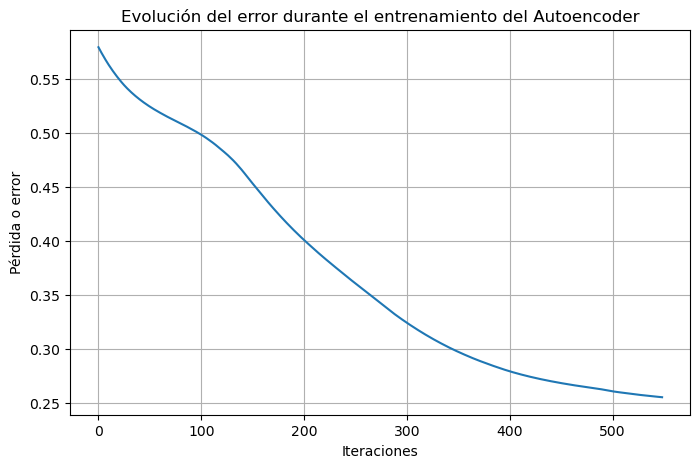

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(autoencoder.loss_curve_)

plt.xlabel("Iteraciones")
plt.ylabel("Pérdida o error")
plt.title("Evolución del error durante el entrenamiento del Autoencoder")
plt.grid(True)
plt.show()

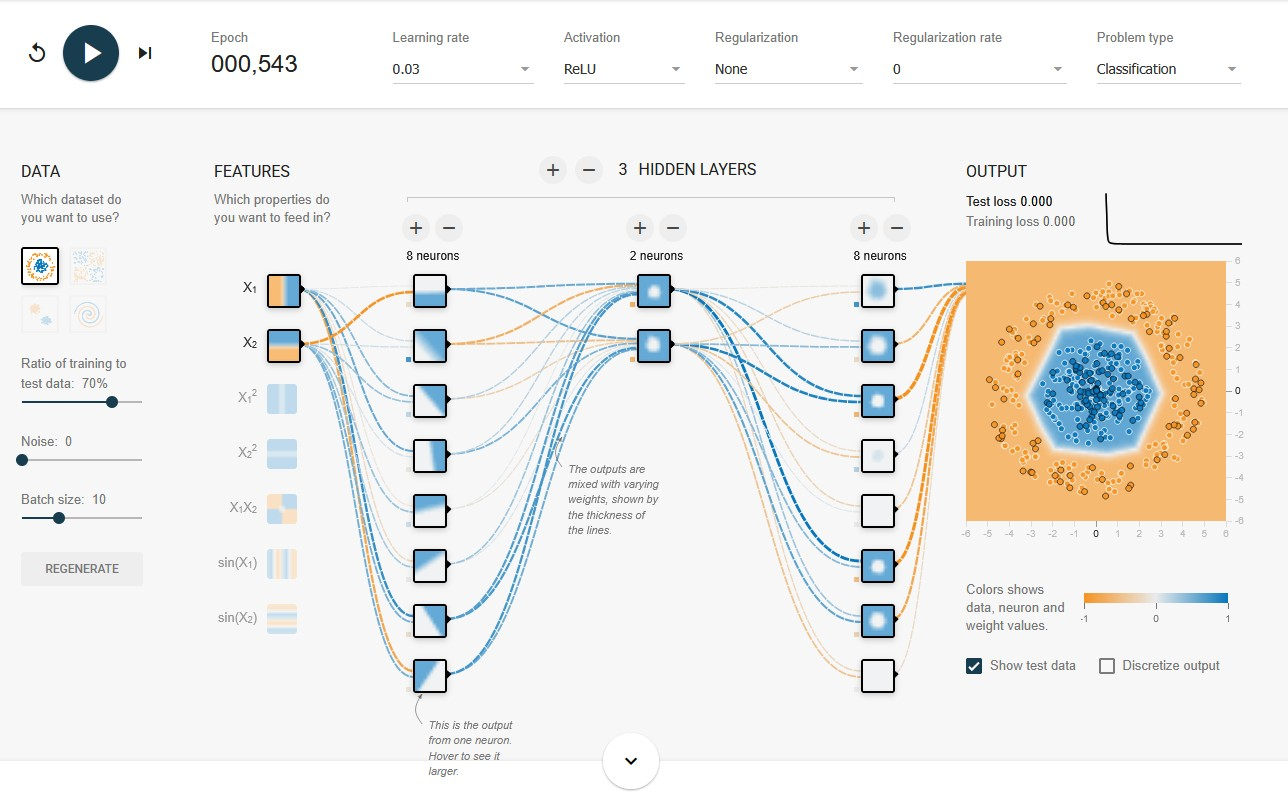

In [69]:
from IPython.display import Image, display

display(Image(filename="tensorflow_playground_resultado.jpg"))

## Evaluar el error de reconstrucción

El Autoencoder intenta reconstruir los mismos datos que recibe como entrada.

Después del entrenamiento, se calcula el error promedio entre los datos originales y los datos reconstruidos.

Un error bajo indica que la red neuronal logró aprender una representación adecuada de las estaciones.

In [71]:
X_reconstruido = autoencoder.predict(X)

error_reconstruccion = np.mean((X - X_reconstruido) ** 2)

print("Error promedio de reconstrucción:", error_reconstruccion)

Error promedio de reconstrucción: 0.5111485328691077


## Obtener la representación comprimida

En este paso se extrae la capa comprimida del Autoencoder.

Esta capa contiene dos neuronas, por lo tanto cada estación queda representada por dos valores numéricos.

Estos dos valores resumen la información más importante de las variables originales y serán usados para agrupar las estaciones.

In [73]:
def relu(x):
    return np.maximum(0, x)

# Primera capa oculta
capa_1 = relu(np.dot(X, autoencoder.coefs_[0]) + autoencoder.intercepts_[0])

# Capa comprimida de 2 neuronas
capa_comprimida = relu(np.dot(capa_1, autoencoder.coefs_[1]) + autoencoder.intercepts_[1])

df_comprimido = pd.DataFrame(
    capa_comprimida,
    columns=["neurona_1", "neurona_2"]
)

df_comprimido.head()

,neurona_1,neurona_2
0,4.041332,2.066879
1,2.462297,2.326951
2,2.820906,1.953346
3,2.374488,0.114759
4,4.475082,0.669747


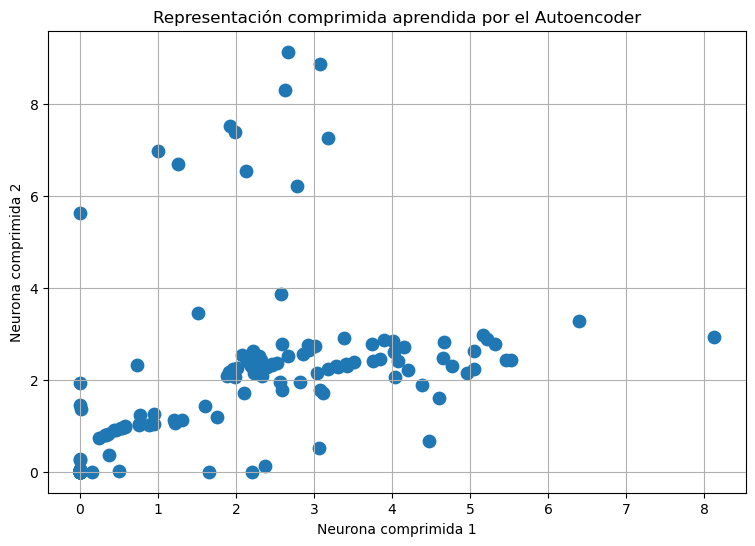

In [74]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_comprimido["neurona_1"],
    df_comprimido["neurona_2"],
    s=80
)

plt.xlabel("Neurona comprimida 1")
plt.ylabel("Neurona comprimida 2")
plt.title("Representación comprimida aprendida por el Autoencoder")
plt.grid(True)
plt.show()

## Buscar el mejor número de clusters

Después de obtener la representación comprimida, se aplica K-Means para formar grupos de estaciones.

Pero antes de entrenar el modelo final, se prueba con diferentes cantidades de clusters.

Para evaluar cada opción se utiliza Silhouette Score. Este indicador permite analizar qué tan bien separadas están las estaciones dentro de los grupos.

Mientras más alto sea el valor, mejor será la separación entre clusters.

In [76]:
silhouette_scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(df_comprimido)
    score = silhouette_score(df_comprimido, clusters)
    silhouette_scores[k] = score
    print(f"K={k} | Silhouette Score={score:.4f}")

K=2 | Silhouette Score=0.5622
K=3 | Silhouette Score=0.6422
K=4 | Silhouette Score=0.6045
K=5 | Silhouette Score=0.5945
K=6 | Silhouette Score=0.5649
K=7 | Silhouette Score=0.5467


In [77]:
mejor_k = max(silhouette_scores, key=silhouette_scores.get)

print("Mejor número de clusters:", mejor_k)

Mejor número de clusters: 3


## Entrenar el modelo K-Means final

Con el mejor número de clusters identificado, se entrena el modelo K-Means final.

Este modelo asigna cada estación a un grupo según la similitud de sus características comprimidas por el Autoencoder.

In [79]:
kmeans_final = KMeans(n_clusters=mejor_k, random_state=42, n_init=10)

clusters = kmeans_final.fit_predict(df_comprimido)

clusters[:10]

array([0, 0, 0, 2, 0, 0, 0, 2, 0, 0], dtype=int32)

## Agregar los clusters al dataset original

En este paso se agregan los resultados del modelo al dataset original.

Se añaden tres columnas nuevas:

- neurona_1: primera variable comprimida aprendida por el Autoencoder.
- neurona_2: segunda variable comprimida aprendida por el Autoencoder.
- cluster: grupo asignado por K-Means.

Esto permite interpretar a qué grupo pertenece cada estación.

In [81]:
df_resultado = df.loc[datos.index].copy()

df_resultado["neurona_1"] = df_comprimido["neurona_1"].values
df_resultado["neurona_2"] = df_comprimido["neurona_2"].values
df_resultado["cluster"] = clusters

df_resultado[[
    "nom_est",
    "id_trazado",
    "tipo_esta",
    "area_est",
    "num_acc",
    "cap_biart",
    "num_vag",
    "cap_art",
    "cluster"
]].head()

,nom_est,id_trazado,tipo_esta,area_est,num_acc,cap_biart,num_vag,cap_art,cluster
0,AV. Chile,TZ008,4,694.56,2,120,3,224,0
1,CAN,TZ016,4,289.44,1,120,2,140,0
2,Campín - UAN,TZ008,4,491.28,2,120,2,152,0
3,San Diego,TZ018,4,1392.36,2,144,2,144,2
4,Granja - Kr 77,TZ005,2,1540.00,2,144,4,248,0


## Analizar las estaciones por cluster

En este paso se revisan las estaciones que pertenecen a cada cluster.

Esto permite interpretar si el modelo agrupó estaciones con características similares, por ejemplo estaciones grandes, estaciones con más accesos o estaciones con mayor capacidad.

## Crear un resumen estadístico por cluster

Para comprender mejor cada grupo se calcula el promedio de las principales variables por cluster.

Esto permite comparar los grupos y describirlos de forma más clara.

In [84]:
resumen_clusters = df_resultado.groupby("cluster")[[
    "long_est",
    "ancho_est",
    "area_est",
    "num_acc",
    "acc_esp",
    "acc_depr",
    "acc_puent",
    "cap_biart",
    "num_vag",
    "cap_art"
]].mean().round(2)

resumen_clusters["cantidad_estaciones"] = df_resultado.groupby("cluster").size()

resumen_clusters


,long_est,ancho_est,area_est,num_acc,acc_esp,acc_depr,acc_puent,cap_biart,num_vag,cap_art,cantidad_estaciones
cluster,,,,,,,,,,,
0,134.73,3.68,499.99,1.17,0.06,0.01,1.10,110.23,2.49,157.54,70
1,412.80,0.00,0.00,1.27,0.64,0.00,0.64,121.55,1.45,168.36,11
2,129.26,3.64,487.01,1.68,1.52,0.12,0.04,91.65,2.22,136.41,69


## Visualizar los clusters

Como la representación comprimida tiene dos neuronas, se puede graficar cada estación en un plano de dos dimensiones.

Cada punto representa una estación y el color representa el cluster asignado.

Esta gráfica permite observar visualmente cómo quedaron agrupadas las estaciones.

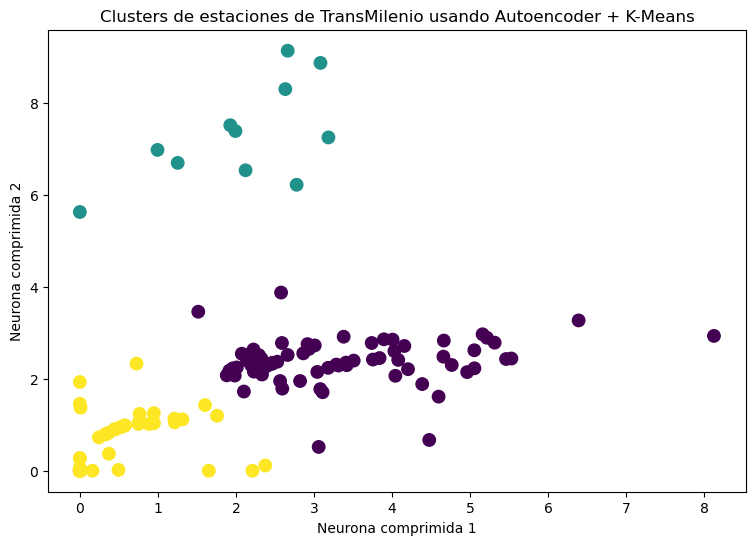

In [86]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_resultado["neurona_1"],
    df_resultado["neurona_2"],
    c=df_resultado["cluster"],
    s=80
)

plt.xlabel("Neurona comprimida 1")
plt.ylabel("Neurona comprimida 2")
plt.title("Clusters de estaciones de TransMilenio usando Autoencoder + K-Means")
plt.show()

## Visualización con nombres de estaciones

En esta gráfica se muestran los nombres de las estaciones sobre cada punto.

Esto ayuda a identificar visualmente qué estaciones quedaron cerca entre sí y a qué cluster pertenecen.

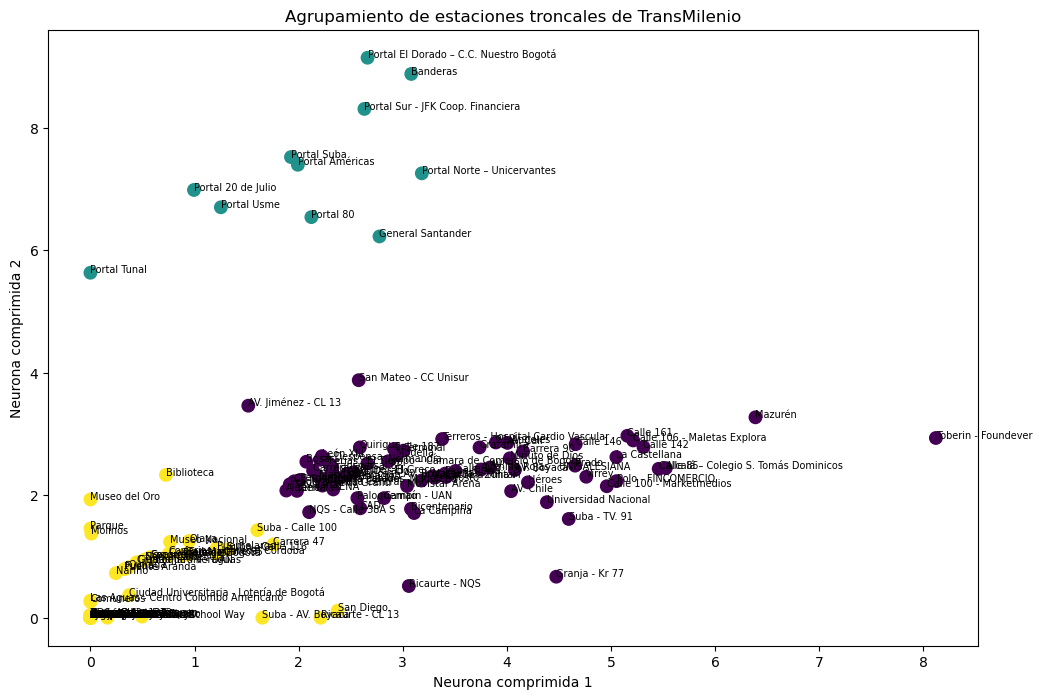

In [88]:
plt.figure(figsize=(12, 8))

plt.scatter(
    df_resultado["neurona_1"],
    df_resultado["neurona_2"],
    c=df_resultado["cluster"],
    s=80
)

for i, nombre in enumerate(df_resultado["nom_est"]):
    plt.text(
        df_resultado["neurona_1"].iloc[i],
        df_resultado["neurona_2"].iloc[i],
        nombre,
        fontsize=7
    )

plt.xlabel("Neurona comprimida 1")
plt.ylabel("Neurona comprimida 2")
plt.title("Agrupamiento de estaciones troncales de TransMilenio")
plt.show()

In [89]:
df_resultado.to_csv("resultado_autoencoder_transmilenio.csv", index=False, encoding="utf-8-sig")

print("Archivo guardado correctamente.")

Archivo guardado correctamente.


## Bibliografía

Trask, A. W. (2019). *Grokking Deep Learning*. Manning Publications.
https://www.manning.com/books/grokking-deep-learning

TensorFlow. (s. f.). *A Neural Network Playground*.
https://playground.tensorflow.org/

Scikit-learn developers. (s. f.). *scikit-learn: Machine Learning in Python*.
https://scikit-learn.org/

Scikit-learn developers. (s. f.). *KMeans*. Scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

Scikit-learn developers. (s. f.). *MLPRegressor*. Scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

Scikit-learn developers. (s. f.). *StandardScaler*. Scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

Scikit-learn developers. (s. f.). *Silhouette Score*. Scikit-learn documentation.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html

NumPy developers. (s. f.). *NumPy documentation*.
https://numpy.org/doc/stable/

Pandas developers. (s. f.). *Pandas documentation*.
https://pandas.pydata.org/docs/

Matplotlib developers. (s. f.). *Matplotlib documentation*.
https://matplotlib.org/stable/index.html
